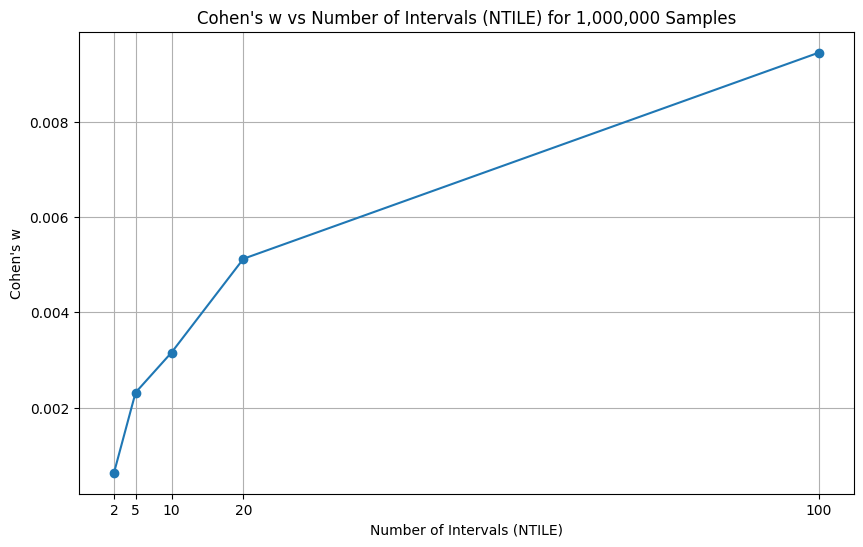

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_cohens_w_from_ndarray(data, num_intervals):
    """
    Calculate Cohen's w for a given ndarray input and number of intervals.

    Parameters:
        data (ndarray): Input data, size N x 2, where column 0 is A and column 1 is the response (0 or 1).
        num_intervals (int): Number of intervals for NTILE.

    Returns:
        float: Cohen's w for the given number of intervals.
    """
    A = data[:, 0]  # Column 0: A
    response = data[:, 1]  # Column 1: Response

    # Assign NTILE labels
    ntile_labels = np.ceil(A * num_intervals).astype(int)
    ntile_labels[ntile_labels > num_intervals] = num_intervals  # Cap labels to num_intervals

    # Contingency table (observed counts)
    observed = np.zeros((num_intervals, 2))
    for i in range(num_intervals):
        observed[i, 0] = np.sum((ntile_labels == (i + 1)) & (response == 0))
        observed[i, 1] = np.sum((ntile_labels == (i + 1)) & (response == 1))

    # Expected counts under independence
    row_totals = observed.sum(axis=1)
    col_totals = observed.sum(axis=0)
    grand_total = observed.sum()
    expected = np.outer(row_totals, col_totals) / grand_total

    # Chi-squared statistic
    chi_squared = np.sum((observed - expected) ** 2 / expected)

    # Cohen's w
    w = np.sqrt(chi_squared / grand_total)
    return w

# Generate data: 1,000,000 samples
np.random.seed(42)
num_samples = 1_000_000
data = np.hstack((
    np.random.rand(num_samples).reshape(-1, 1),  # A (uniformly distributed between 0 and 1)
    np.random.choice([0, 1], size=(num_samples, 1))  # Response (random binary)
))

# Intervals to test
intervals = [2, 5, 10, 20, 100]

# Calculate Cohen's w for each interval size
cohens_ws = [calculate_cohens_w_from_ndarray(data, n) for n in intervals]

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(intervals, cohens_ws, marker='o')
plt.title("Cohen's w vs Number of Intervals (NTILE) for 1,000,000 Samples")
plt.xlabel("Number of Intervals (NTILE)")
plt.ylabel("Cohen's w")
plt.xticks(intervals)
plt.grid(True)
plt.show()

# Need ways in which to generate features & evaluate...

Evaluation:
* Information theory
* Cohens D
* Conhens W (group into NTILE(25, 100) first)

Crossing:
* Multiple "Raw" ... evaluate above
* Cross tab "Raw" (5 by 5) and (10 by 10) and use Cohens W

Splitting up:
* Weeks - first 4 weeks
* Months - all 13 months (28 days)
* QUarters - 12 weeks, 12 weeks, 12 weeks, 13 weeks
* For each, num tran, tran item, $

What else:
* by category ... % ... use different levels .. need to look at these
* by category raw
* by category L2 ???

What I imagine:
* crossing num trans immediate quarter by other three ... is is both recency as well as frequency?
*